<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda/blob/main/Insurance_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install and Import

In [ ]:
!pip install -q numpy pandas matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
np.random.seed(42)

In [ ]:
df = pd.read_csv("insurance.csv")
df.shape

(1338, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#target feature is charges -- continuous value so regression problem.

In [ ]:
#Add an index col
df.reset_index(inplace=True)
df.rename(columns={"index": "id"}, inplace=True)
df.head()

,id,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


#Data Quality Checks

Data Quality Checks:

0. Overview
1. Missing values summary
2. Duplicates
3. Data Type validation
4. Constant and quasi constant columns
5. ID like columns
6. String inconsistencies
7. High null columns
8. High zero columns

##0. Overview

In [ ]:
df.shape

(1338, 8)

In [ ]:
df.dtypes

,0
id,int64
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df.info()
##so no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [ ]:
df.describe()

,id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,668.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.250000,27.000000,26.296250,0.000000,4740.287150
50%,668.500000,39.000000,30.400000,1.000000,9382.033000
75%,1002.750000,51.000000,34.693750,2.000000,16639.912515
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.columns

Index(['id', 'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.nunique()

,0
id,1338
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [ ]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

##1. Missing Values Check

In [ ]:
df.isna().sum()

,0
id,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percentage = (df.isna().mean()*100).sort_values(ascending=False)
missing_values = pd.DataFrame({"missing_count": missing_count, "missing_percentage": missing_percentage})
missing_values

,missing_count,missing_percentage
id,0,0.0
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


##2. Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated(keep=False)]

,id,age,sex,bmi,children,smoker,region,charges


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

##Data Type Validation

In [ ]:
df.dtypes

,0
id,int64
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


##4. Constant and Quasi Constant Columns

In [ ]:
#constant means ONE VALUE for all the columns lol how can i forget
#quasi constant means that are mostly constant,
#they will not provide sufficient information to the model either. in this case if like 90% of the values are the same, they are not useful?ig

In [ ]:
n_rows=len(df)
nunique = df.nunique()
constant_cols = nunique[nunique==1].index.to_list()
print(constant_cols)

[]


In [ ]:
df.nunique().sort_values(ascending=True)

,0
sex,2
smoker,2
region,4
children,6
age,47
bmi,548
charges,1337
id,1338


In [ ]:
quasi_constant_cols = []
for col in df.columns:
  top_freq= df[col].value_counts(normalize=True,dropna=False).values[0]
  if top_freq > 0.9 and col not in constant_cols:
    quasi_constant_cols.append(col)

quasi_constant_cols

[]

##5. ID-like columns  

In [ ]:
id_like_cols=[]
for col in df.columns:
  if df[col].nunique() > 0.95*n_rows:
    id_like_cols.append(col)
id_like_cols

['id', 'charges']

In [ ]:
#charges is the target so theres no need to remove it for the model.
#id should be removed.

##6. String Inconsistencies

In [ ]:
def text_fix():
  for col in categorical_cols:
    df[col]=df[col].str.lower()
    df[col]=df[col].str.strip()
    return

text_fix()
df[categorical_cols].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [ ]:
for col in categorical_cols:
  print(df[col].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


##7. High Null Columns

In [ ]:
df.isna().sum()

,0
id,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#percentage null
null_count = df.isna().sum()
null_percentage = (df.isna().mean()*100)
null_values = pd.DataFrame({"null_count": null_count, "null_percentage": null_percentage})
null_values

,null_count,null_percentage
id,0,0.0
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


##High Zero Columns

In [ ]:
high_zero_threshold = 40
zero_values = (df[numeric_cols]==0).mean()*100
zero_values.sort_values(ascending=False,inplace=True)
zero_values[zero_values>high_zero_threshold]

,0
children,42.899851


#Univariate Analysis

Checks of Central Measures

Checks of Dispersion

Checks of Skewness

Checks of Kurtosis

Categorical - frequency, countplots

In [ ]:
df.describe()

,id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,668.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.250000,27.000000,26.296250,0.000000,4740.287150
50%,668.500000,39.000000,30.400000,1.000000,9382.033000
75%,1002.750000,51.000000,34.693750,2.000000,16639.912515
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


In [ ]:
description = df[numeric_cols].describe().T
description["skew"] = df[numeric_cols].skew(numeric_only=True)
description["kurtosis"] = df[numeric_cols].kurtosis(numeric_only=True)
description["range"]= description["max"]-description["min"]
description["iqr"] = description["75%"]-description["25%"]
description["mode"] = df[numeric_cols].mode().T
description["variance"] = df[numeric_cols].var()
description


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,range,iqr,mode,variance
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000,0.055673,-1.245088,46.00000,24.000000,18.0000,1.974014e+02
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000,0.284047,-0.050732,37.17000,8.397500,32.3000,3.718788e+01
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000,0.938380,0.202454,5.00000,2.000000,0.0000,1.453213e+00
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801,1.515880,1.606299,62648.55411,11899.625365,1639.5631,1.466524e+08


##Univariate Analysis of Numerical Features

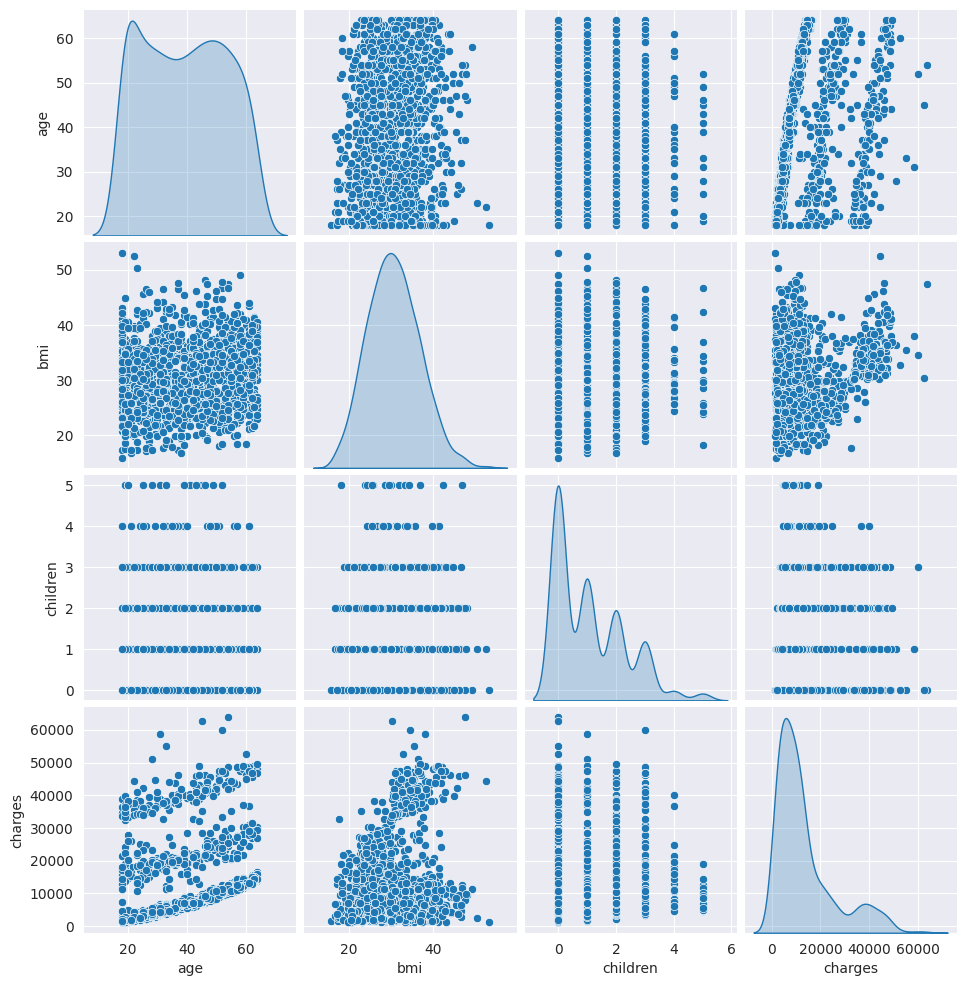

In [ ]:
sns.pairplot(df[numeric_cols], diag_kind="kde")
plt.show()

##Boxplots

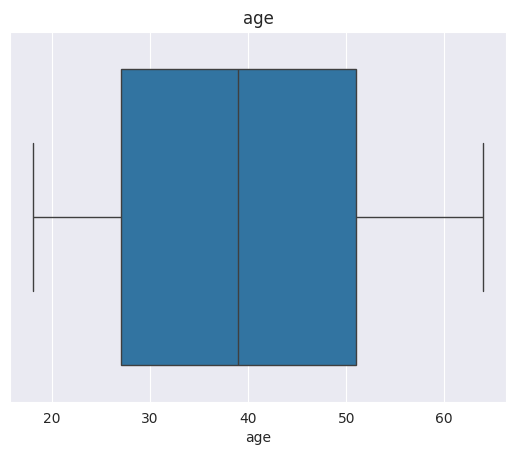

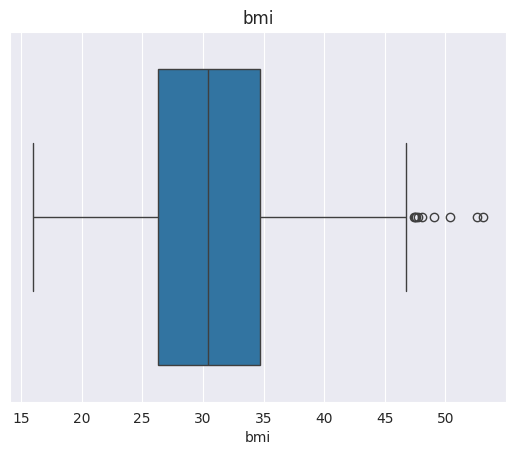

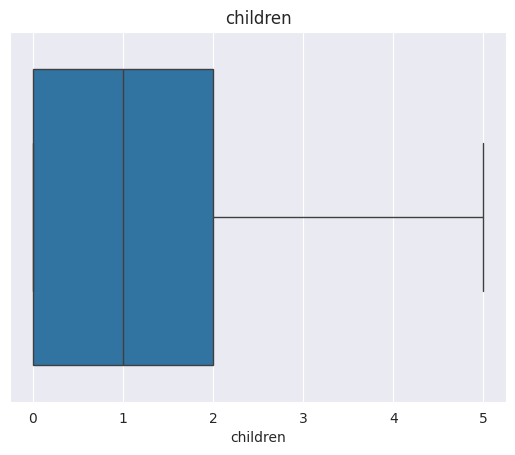

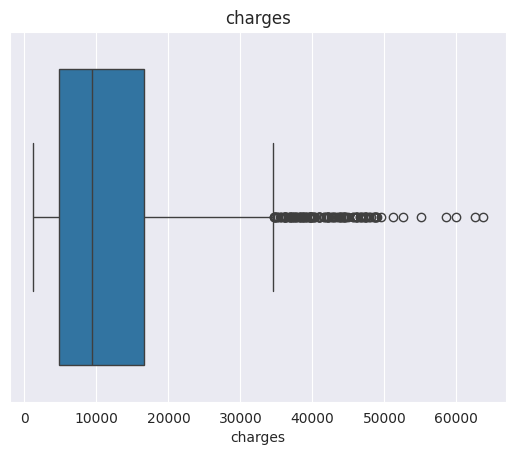

In [ ]:
for cols in numeric_cols:
  sns.boxplot(data=df, x=cols)
  plt.title(cols)
  plt.show()

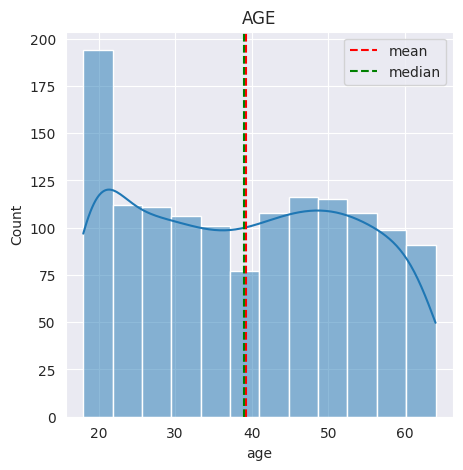

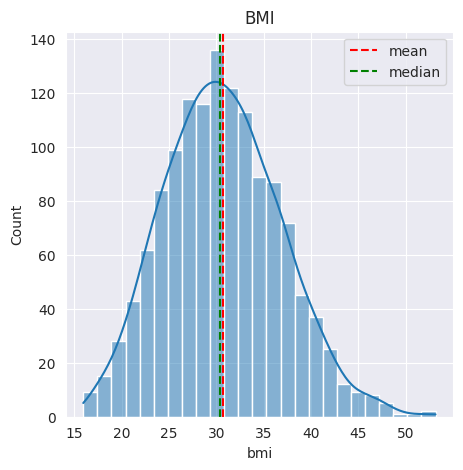

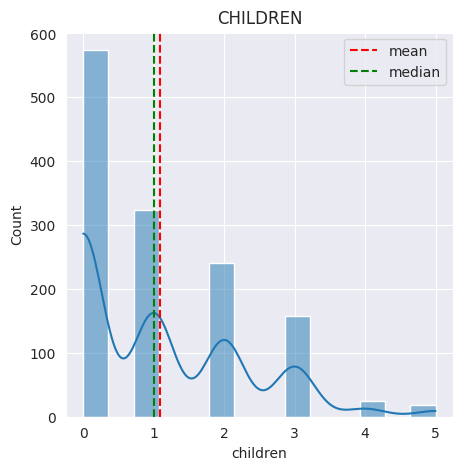

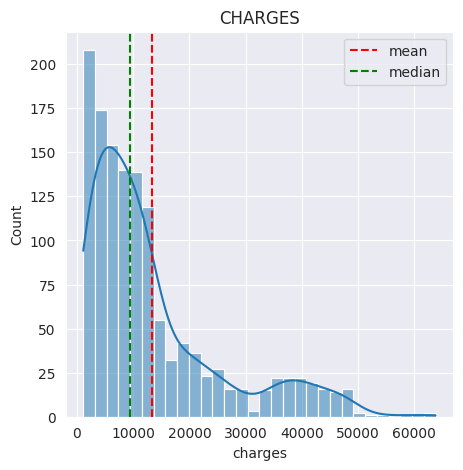

In [ ]:

for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col], kde=True)
  plt.axvline(df[col].mean(), color="red", linestyle="--", label="mean")
  plt.axvline(df[col].median(), color="green", linestyle="--", label="median")
  plt.title(col.upper())
  plt.legend()
  plt.show()

#Univariate Analysis of Categorical Features

In [ ]:
#Countplot n Frequency

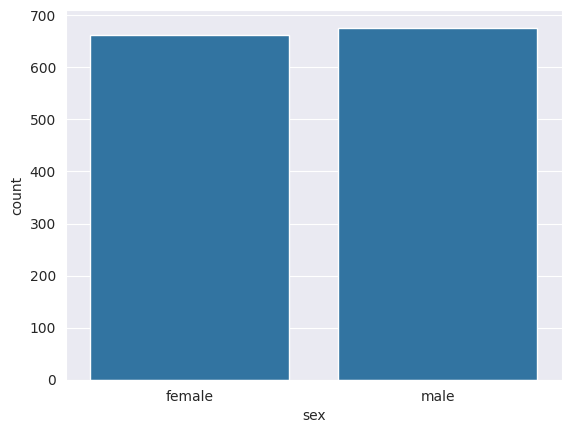

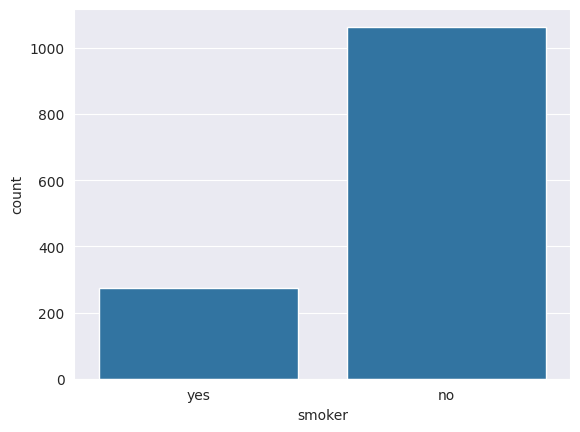

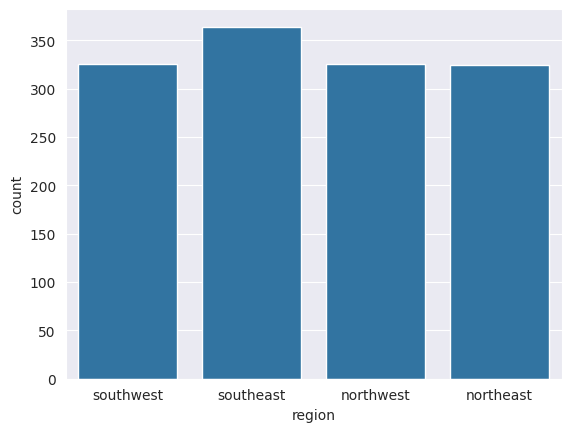

In [ ]:
for col in categorical_cols:
  sns.countplot(x=df[col])
  plt.show()

In [ ]:
for col in categorical_cols:
  print (col)
  print (df[col].value_counts().sort_values())

sex
sex
female    662
male      676
Name: count, dtype: int64
smoker
smoker
yes     274
no     1064
Name: count, dtype: int64
region
region
northeast    324
southwest    325
northwest    325
southeast    364
Name: count, dtype: int64


In [ ]:
for col in categorical_cols:
  print (col)
  print (df[col].value_counts(normalize=True).sort_values())

sex
sex
female    0.494768
male      0.505232
Name: proportion, dtype: float64
smoker
smoker
yes    0.204783
no     0.795217
Name: proportion, dtype: float64
region
region
northeast    0.242152
southwest    0.242900
northwest    0.242900
southeast    0.272048
Name: proportion, dtype: float64


#Bivariate Analysis

In [ ]:
num_to_num_pairs = []
for i in range(len(numeric_cols)):
  for j in range(i+1, len(numeric_cols)):
    num_to_num_pairs.append((numeric_cols[i], numeric_cols[j]))
num_to_num_pairs

[('age', 'bmi'),
 ('age', 'children'),
 ('age', 'charges'),
 ('bmi', 'children'),
 ('bmi', 'charges'),
 ('children', 'charges')]

In [ ]:
num_to_cat_pairs = []
for i in range(len(numeric_cols)):
  for j in range(len(categorical_cols)):
    num_to_cat_pairs.append((numeric_cols[i], categorical_cols[j]))
num_to_cat_pairs

[('age', 'sex'),
 ('age', 'smoker'),
 ('age', 'region'),
 ('bmi', 'sex'),
 ('bmi', 'smoker'),
 ('bmi', 'region'),
 ('children', 'sex'),
 ('children', 'smoker'),
 ('children', 'region'),
 ('charges', 'sex'),
 ('charges', 'smoker'),
 ('charges', 'region')]

In [ ]:
cat_to_cat_pairs = []
for i in range(len(categorical_cols)):
  for j in range(i+1, len(categorical_cols)):
    cat_to_cat_pairs.append((categorical_cols[i], categorical_cols[j]))
cat_to_cat_pairs

[('sex', 'smoker'), ('sex', 'region'), ('smoker', 'region')]

##Numerical to Numerical

###scatterplot

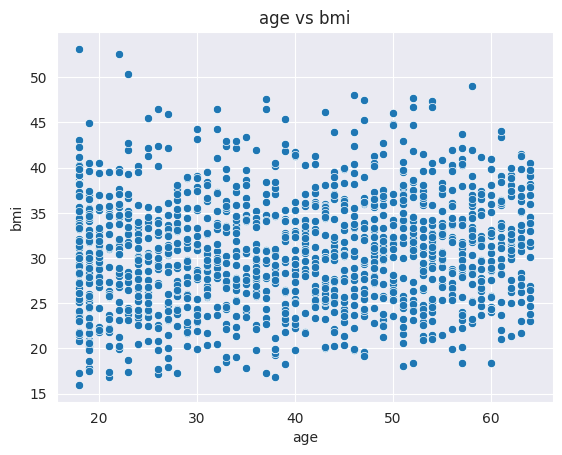

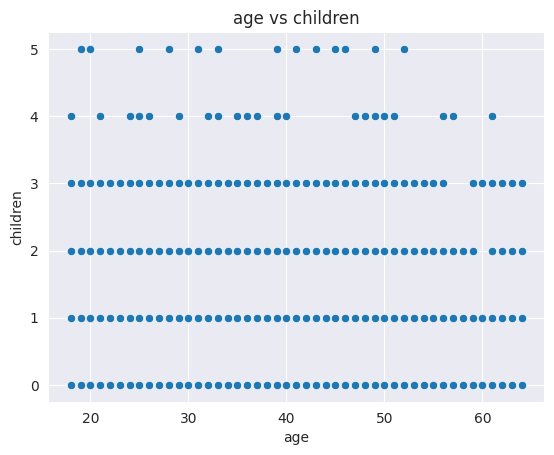

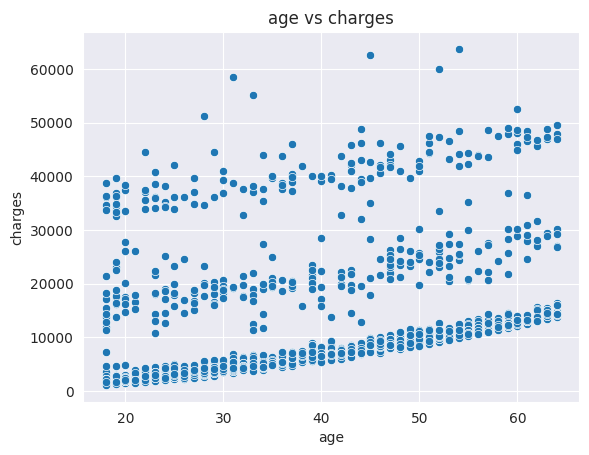

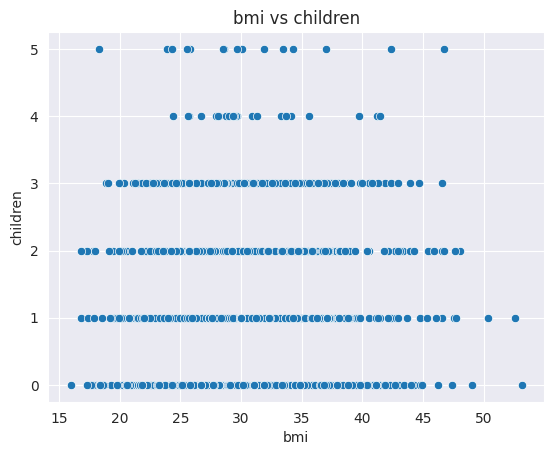

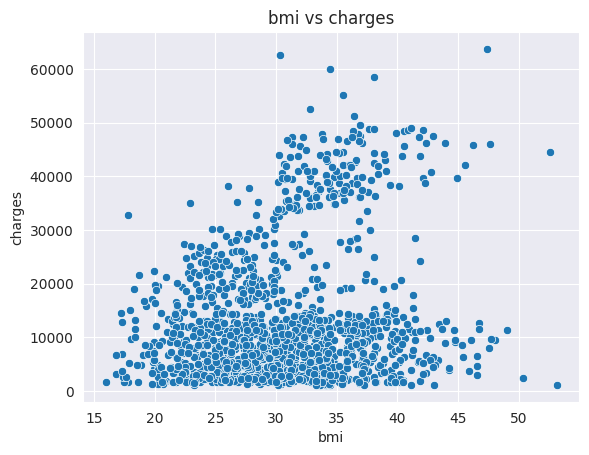

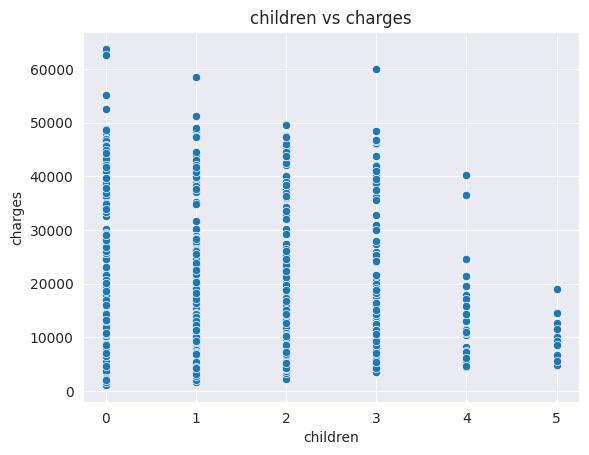

In [ ]:
for x,y in num_to_num_pairs:
  sns.scatterplot(data=df, x=x, y=y)
  plt.title(f"{x} vs {y}")
  plt.show()

###Correlation

In [ ]:
df[numeric_cols].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


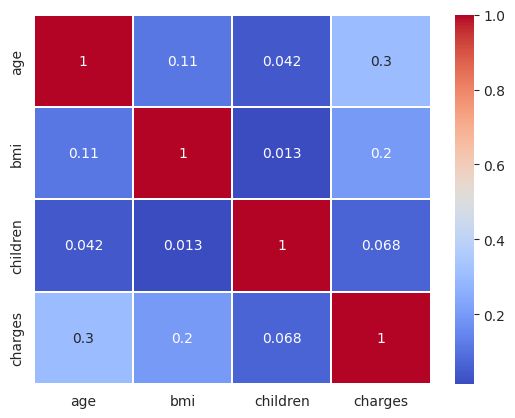

In [ ]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.2)
plt.show()

###Pearson Correlation Coefficient

--if p is low <0.05 then it is confident that there is a relationship or else it is not.

--PCC measures correlation through a linear lens, it is possible that the correlation is not linear but some other type like quadratic.

In [ ]:
!pip install -q scipy
from scipy.stats import pearsonr

In [ ]:
for x,y in num_to_num_pairs:
  r,p = pearsonr(df[x],df[y])
  print(f"Col 1:{x}, Col 2:{y} r: {r:.4f}, p: {p:.4f} \n\n")


Col 1:age, Col 2:bmi r: 0.1093, p: 0.0001 


Col 1:age, Col 2:children r: 0.0425, p: 0.1205 


Col 1:age, Col 2:charges r: 0.2990, p: 0.0000 


Col 1:bmi, Col 2:children r: 0.0128, p: 0.6410 


Col 1:bmi, Col 2:charges r: 0.1983, p: 0.0000 


Col 1:children, Col 2:charges r: 0.0680, p: 0.0129 




##Numerical vs Categorical

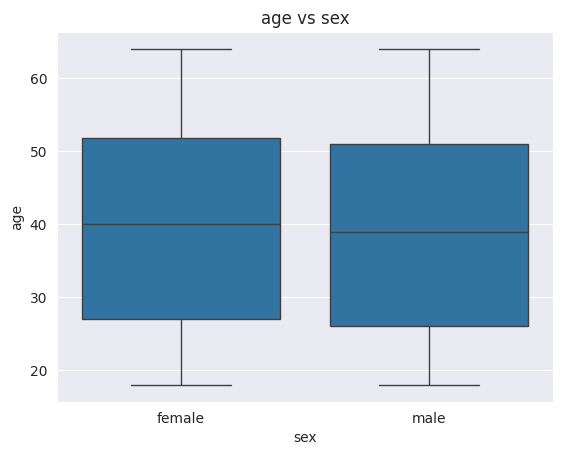

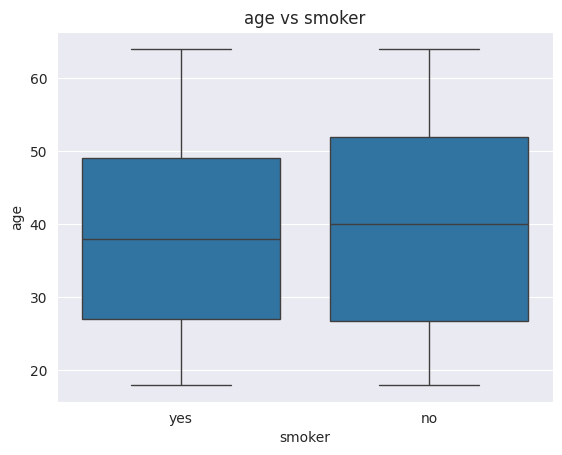

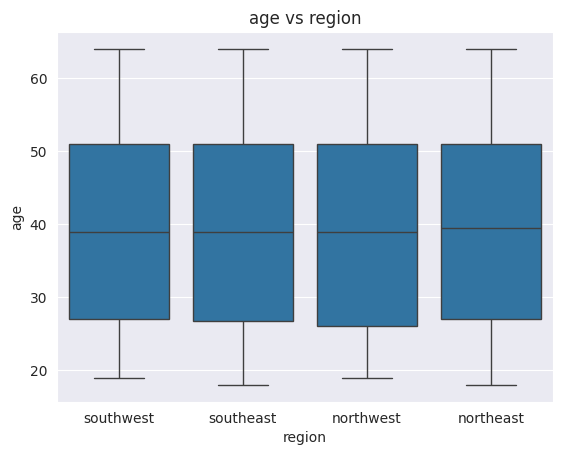

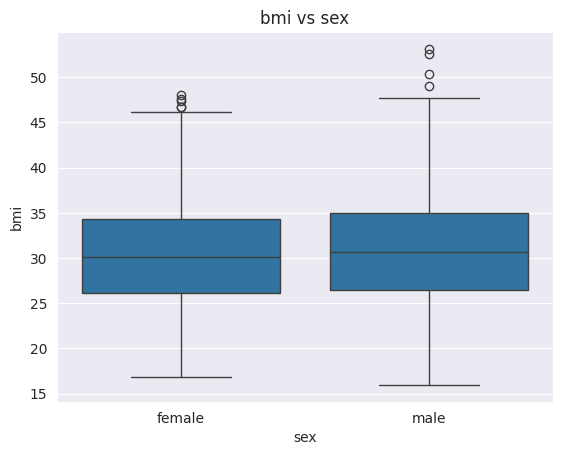

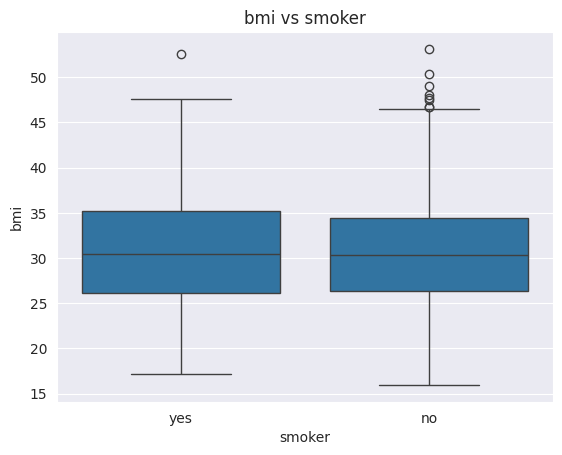

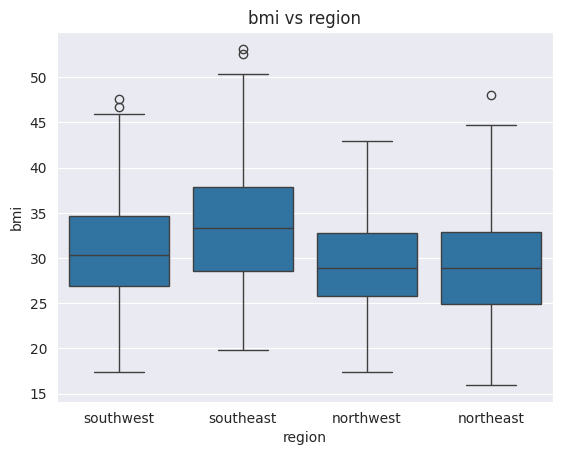

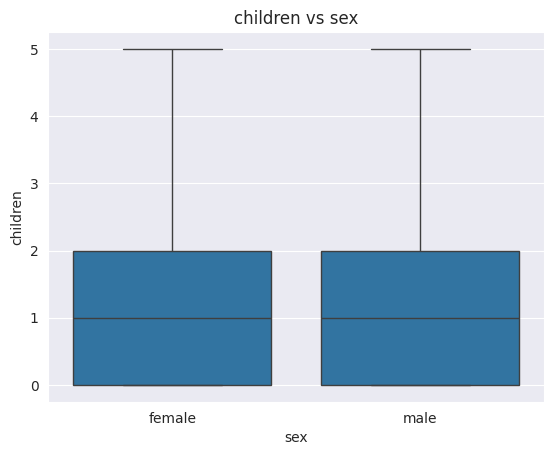

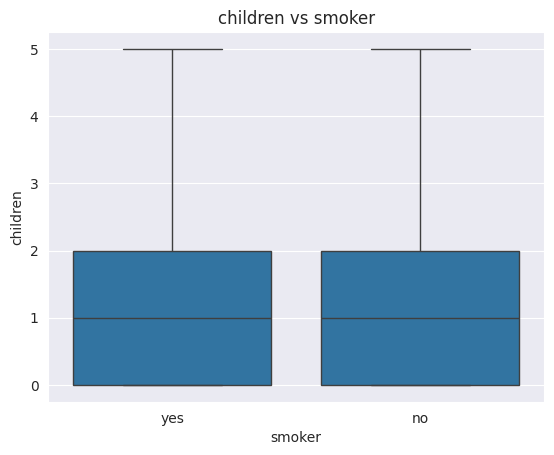

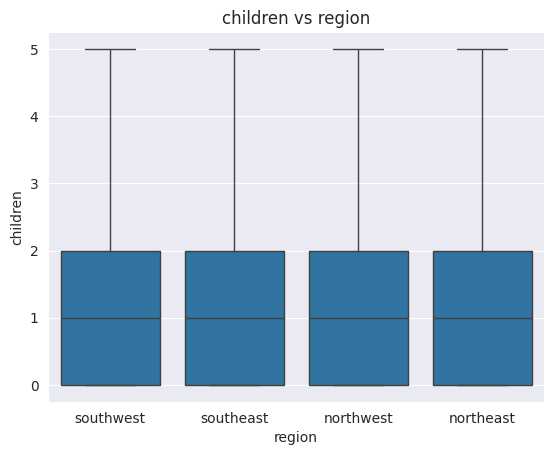

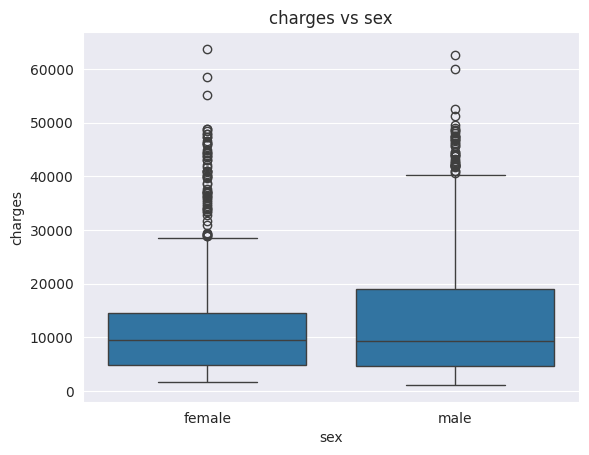

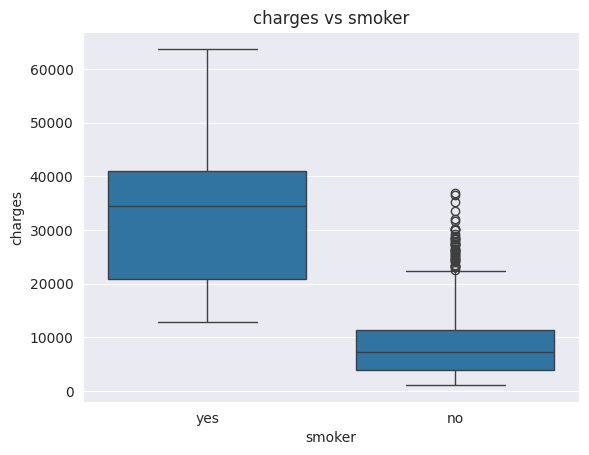

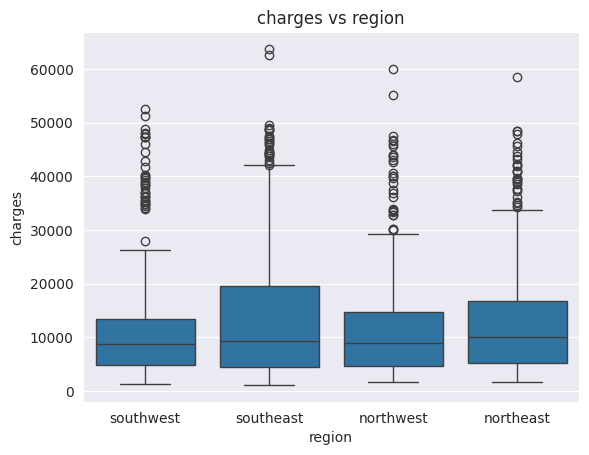

In [ ]:
for x,y in num_to_cat_pairs:
  sns.boxplot(data=df, x=y, y=x)
  plt.title(f"{x} vs {y}")
  plt.show()
  print("\n")

##Grouped Statistics

In [ ]:
df[numeric_cols+["sex"]].groupby("sex").mean()

,age,bmi,children,charges
sex,,,,
female,39.503021,30.377749,1.074018,12569.578844
male,38.917160,30.943129,1.115385,13956.751178


In [ ]:
for col in categorical_cols:
  print(df.groupby(col)[numeric_cols].mean(), "\n")

              age        bmi  children       charges
sex                                                 
female  39.503021  30.377749  1.074018  12569.578844
male    38.917160  30.943129  1.115385  13956.751178 

              age        bmi  children       charges
smoker                                              
no      39.385338  30.651795  1.090226   8434.268298
yes     38.514599  30.708449  1.113139  32050.231832 

                 age        bmi  children       charges
region                                                 
northeast  39.268519  29.173503  1.046296  13406.384516
northwest  39.196923  29.199785  1.147692  12417.575374
southeast  38.939560  33.355989  1.049451  14735.411438
southwest  39.455385  30.596615  1.141538  12346.937377 



#Categorical VS Categorical

##CrossTab

In [ ]:
for col1,col2 in cat_to_cat_pairs:
  print(pd.crosstab(df[col1], df[col2], margins=True, margins_name="Total"),"\n")
  print(pd.crosstab(df[col1], df[col2], margins=True, margins_name="Total", normalize=True),"\n")

smoker    no  yes  Total
sex                     
female   547  115    662
male     517  159    676
Total   1064  274   1338 

smoker        no       yes     Total
sex                                 
female  0.408819  0.085949  0.494768
male    0.386398  0.118834  0.505232
Total   0.795217  0.204783  1.000000 

region  northeast  northwest  southeast  southwest  Total
sex                                                      
female        161        164        175        162    662
male          163        161        189        163    676
Total         324        325        364        325   1338 

region  northeast  northwest  southeast  southwest     Total
sex                                                         
female   0.120329   0.122571   0.130792   0.121076  0.494768
male     0.121824   0.120329   0.141256   0.121824  0.505232
Total    0.242152   0.242900   0.272048   0.242900  1.000000 

region  northeast  northwest  southeast  southwest  Total
smoker                       

##Countplots

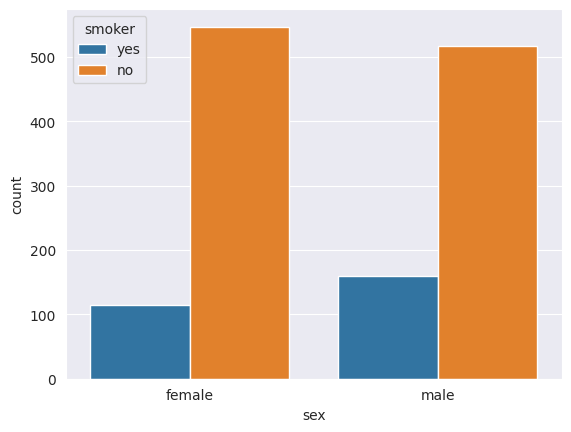

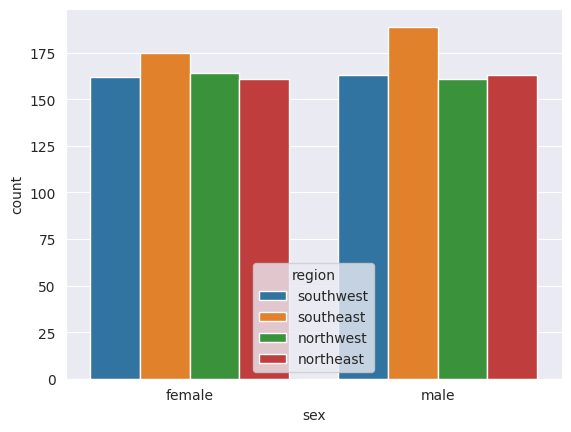

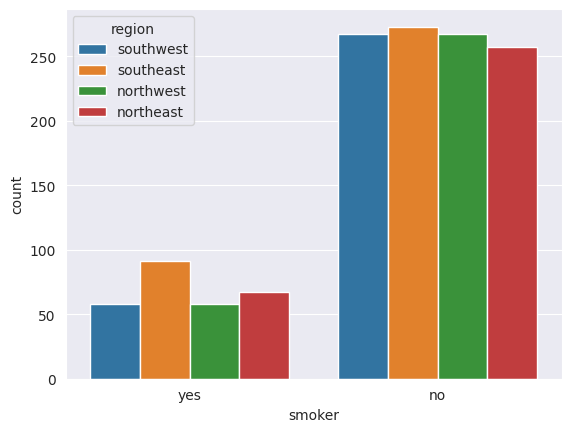

In [ ]:
for col1,col2 in cat_to_cat_pairs:
  sns.countplot(data=df, x=col1, hue=col2)
  plt.show()

#Multivariate Analysis

##pairplot

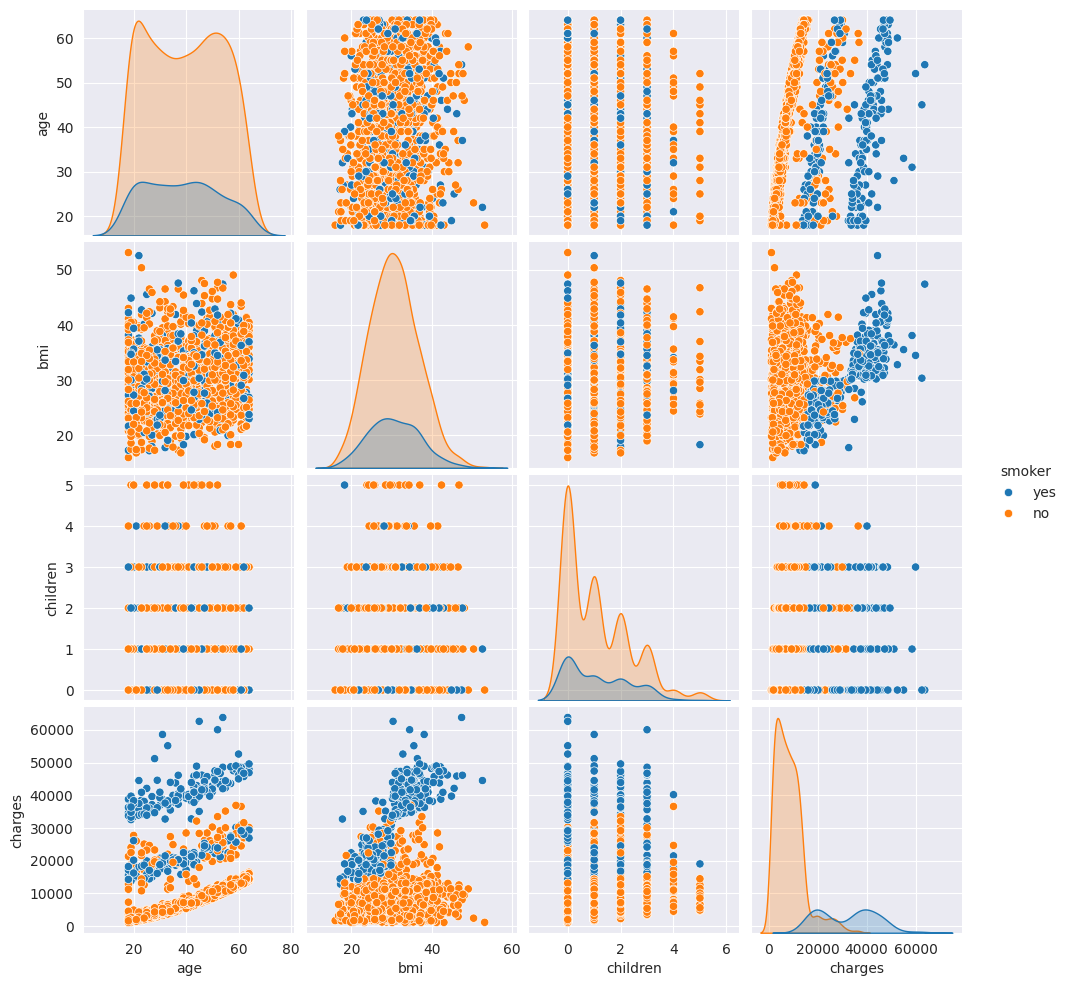

In [272]:
sns.pairplot(df[numeric_cols+["smoker"]], hue="smoker")
plt.show()

Key Insights

In [ ]:
##age increase == charge increase
##smoker == higher charge
##bmi higher w smoker == higher charge than same bmi and non smoker

In [ ]:
##Heatmap already done

##Clustermap

<Figure size 400x400 with 0 Axes>

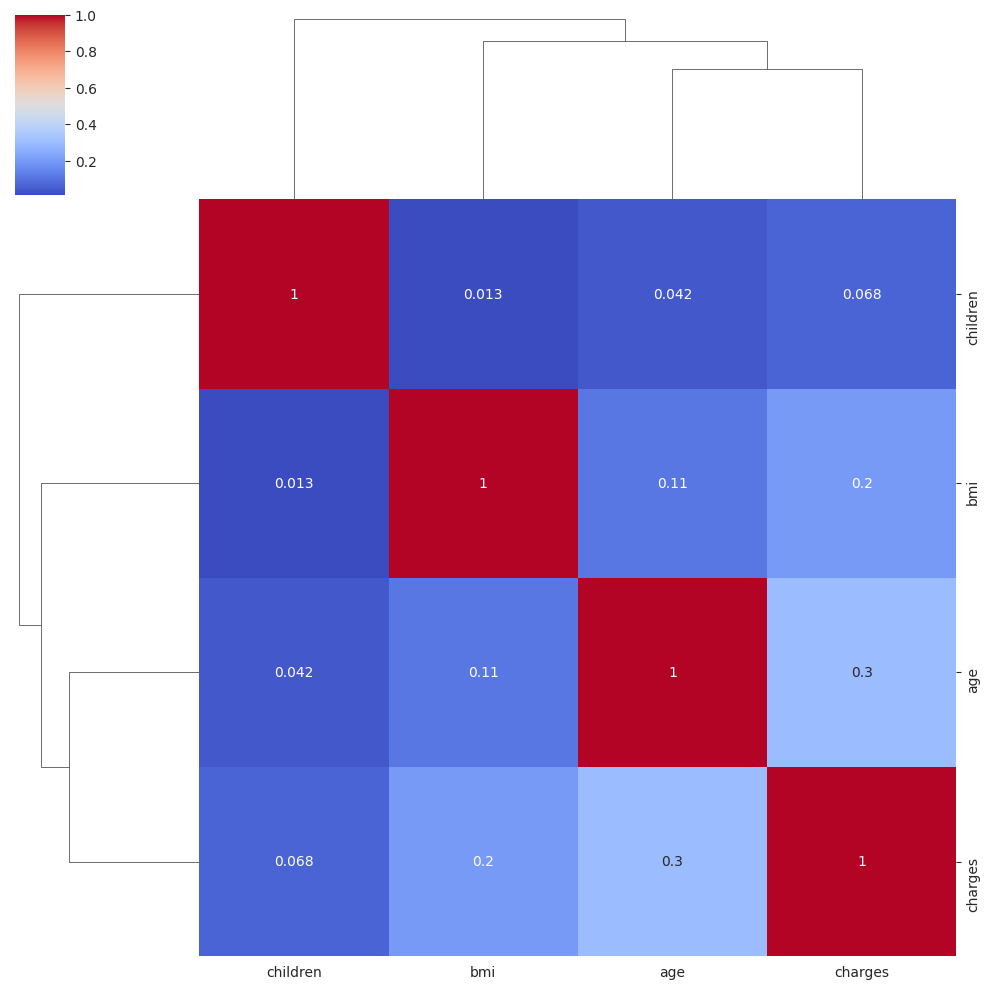

In [273]:
plt.figure(figsize=(4,4))
sns.clustermap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

##Interaction and Subgroup Patterns

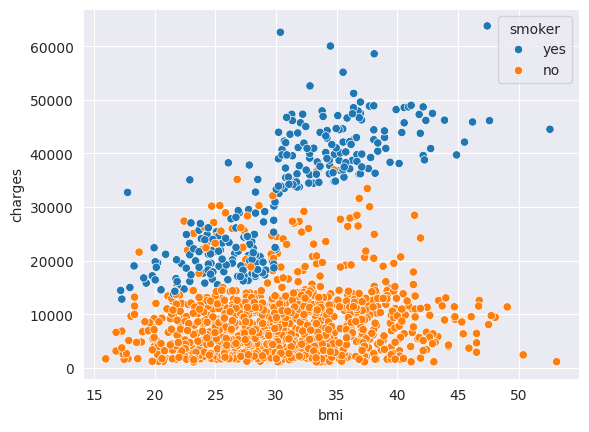

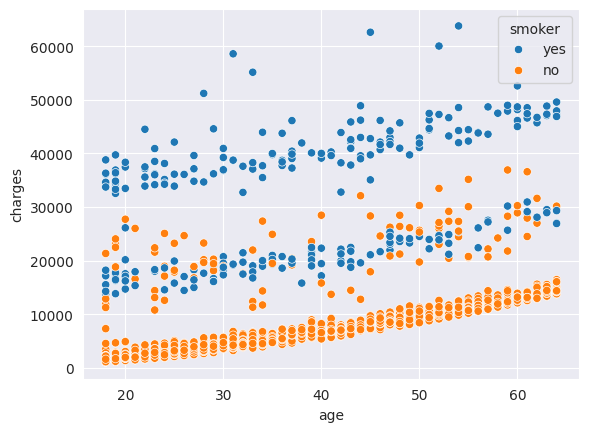

In [275]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.show()
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.show()

#Outlier Detection

In [278]:
df[numeric_cols].describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


We've already made boxplots so onto the next step

##IQR

In [288]:
for col in numeric_cols:
  q3= df[col].quantile(0.75)
  q1= df[col].quantile(0.25)
  iqr = q3-q1
  lower_bound = q1-1.5*iqr
  upper_bound = q3+1.5*iqr
  outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  print("Col: ", col)
  print("Q1", q1)
  print("Q3", q3)
  print("IQR", iqr)
  print("Lower Bound", lower_bound)
  print("Upper Bound", upper_bound)
  print("Outliers ",outliers.value_counts().sum())
  print("Percentage Outliers=", outliers.value_counts().sum()/df.shape[0]*100,"\n")

Col:  age
Q1 27.0
Q3 51.0
IQR 24.0
Lower Bound -9.0
Upper Bound 87.0
Outliers  0
Percentage Outliers= 0.0 

Col:  bmi
Q1 26.29625
Q3 34.69375
IQR 8.3975
Lower Bound 13.7
Upper Bound 47.290000000000006
Outliers  9
Percentage Outliers= 0.672645739910314 

Col:  children
Q1 0.0
Q3 2.0
IQR 2.0
Lower Bound -3.0
Upper Bound 5.0
Outliers  0
Percentage Outliers= 0.0 

Col:  charges
Q1 4740.28715
Q3 16639.912515
IQR 11899.625365
Lower Bound -13109.1508975
Upper Bound 34489.350562499996
Outliers  139
Percentage Outliers= 10.388639760837071 



##Z-SCORE
Z-SCORE: -- assumes normal dist
z= value-mean/std

z>3 is outlier

z<3 is outlier

In [289]:
for col in numeric_cols:
  mean = df[col].mean()
  std = df[col].std()
  z_scores = (df[col]-mean)/std
  outliers = df[z_scores.abs()>3]
  print(col)
  print("Mean", mean)
  print("Std", std)
  print("Outliers", outliers.value_counts().sum())
  print("Percentage Outliers=", outliers.value_counts().sum()/df.shape[0]*100,"\n")

age
Mean 39.20702541106129
Std 14.049960379216172
Outliers 0
Percentage Outliers= 0.0 

bmi
Mean 30.66339686098655
Std 6.098186911679017
Outliers 4
Percentage Outliers= 0.29895366218236175 

children
Mean 1.0949177877429
Std 1.2054927397819095
Outliers 18
Percentage Outliers= 1.345291479820628 

charges
Mean 13270.422265141257
Std 12110.011236693994
Outliers 7
Percentage Outliers= 0.523168908819133 

